# Requirements

In [1]:
# Add as many imports as you need.

# Laboratory Exercise - Run Mode (8 points)

## Introduction
This laboratory assignment's primary objective is to fine-tune a pre-trained language model for binary classification on a dataset consisting of wine reviews. The dataset contains two attributes: **description** and **points**. The description is a brief text describing the wine and the points represent a quality metric ranging from 1 to 100. If some wine has at least 90 points it is considered **exceptional**. Your task involves predicting if some wine is **exceptional** based on its review.

## The Wine Reviews Dataset

Load the dataset using the `datasets` library.

In [2]:
# Write your code here. Add as many boxes as you need.
from datasets import load_dataset

dataset = load_dataset("csv", data_files="wine-reviews (1).csv")
dataset

C:\Users\Korisnik\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['description', 'points'],
        num_rows: 10000
    })
})

In [3]:
df = dataset["train"].to_pandas()
df["points"].unique()

array([ 85,  92,  93,  89,  87,  86,  94,  90,  91,  83,  96,  95,  88,
        84,  82,  81, 100,  80,  97,  98,  99], dtype=int64)

In [4]:

df

,description,points
0,"Translucent in color, silky in the mouth, this...",85
1,"On the palate, this wine is rich and complex, ...",92
2,The producer blends 57% Chardonnay from the Ma...,92
3,"Pure Baga in all its glory, packed with dry an...",93
4,Think of Subsídio as a contribution rather tha...,89
...,...,...
9995,"From the folks at Merryvale, this is a blend o...",92
9996,"An easy, versatile food wine or cocktail sippe...",84
9997,Black-fruit aromas blend nicely into chocolate...,93
9998,"This combines 61% Cabernet Sauvignon, 14% Syra...",90


## Target Extraction
Extract the target **exceptional** for each wine review. If some wine has at least 90 points it is considered **exceptional**.

In [5]:
# Write your code here. Add as many boxes as you need.
def exceptional(e):
  e['label'] = 1 if e['points']>=90 else 0
  return e

In [6]:
dataset = dataset.map(exceptional)
dataset

DatasetDict({
    train: Dataset({
        features: ['description', 'points', 'label'],
        num_rows: 10000
    })
})

In [7]:
df = dataset['train'].to_pandas()
df

,description,points,label
0,"Translucent in color, silky in the mouth, this...",85,0
1,"On the palate, this wine is rich and complex, ...",92,1
2,The producer blends 57% Chardonnay from the Ma...,92,1
3,"Pure Baga in all its glory, packed with dry an...",93,1
4,Think of Subsídio as a contribution rather tha...,89,0
...,...,...,...
9995,"From the folks at Merryvale, this is a blend o...",92,1
9996,"An easy, versatile food wine or cocktail sippe...",84,0
9997,Black-fruit aromas blend nicely into chocolate...,93,1
9998,"This combines 61% Cabernet Sauvignon, 14% Syra...",90,1


In [8]:
dataset['train'] = dataset['train'].remove_columns("points")
dataset = dataset.rename_column("description", "text")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
})

## Dataset Splitting
Partition the dataset into training and testing sets with an 80:20 ratio.


In [9]:
# Write your code here. Add as many boxes as you need.
dataset = dataset["train"].train_test_split(test_size=0.2)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

## Tokenization
Tokenize the texts using the `AutoTokenizer` class.

In [10]:
# Write your code here. Add as many boxes as you need.

dataset["train"].features

{'text': Value(dtype='string', id=None),
 'label': Value(dtype='int64', id=None)}

In [11]:
from transformers import AutoTokenizer

checkpoint = "google-bert/bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

In [12]:
def tokenize(sample):
    return tokenizer(sample["text"], truncation=True)

In [13]:

tokenized_dataset = dataset.map(tokenize, batched=True)

Map: 100%|████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 3255.91 examples/s]


In [14]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [15]:

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

## Fine-tuning a Pre-trained Language Model for Classification
Fine-tune a pre-trained language model for classification on the given dataset.

Define the model using the `AutoModelForSequenceClassification` class.

In [16]:
# Write your code here. Add as many boxes as you need.

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Define the traning parameters using the `TrainingArguments` class.

In [17]:
# Write your code here. Add as many boxes as you need.
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="trainer",
    eval_strategy="epoch",
    per_device_train_batch_size=4,  # batch size for training
    per_device_eval_batch_size=4,  # batch size for evaluation
    metric_for_best_model="f1",
    num_train_epochs=1,
)

In [18]:

import evaluate
import numpy as np

metric = evaluate.load("f1")

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="weighted")

Define the training using the `Trainer` class.

In [20]:
# Write your code here. Add as many boxes as you need.

from transformers import Trainer

trainer = Trainer(
    model,
    training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

In [21]:

import torch

In [22]:

torch.cuda.is_available()

False

In [23]:

device = "cuda" if torch.cuda.is_available() else "cpu"

In [24]:

device

'cpu'

In [25]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [26]:
trainer.train()


Epoch,Training Loss,Validation Loss,F1
1,0.526000,0.537009,0.824409


TrainOutput(global_step=2000, training_loss=0.5601403198242187, metrics={'train_runtime': 7771.9372, 'train_samples_per_second': 1.029, 'train_steps_per_second': 0.257, 'total_flos': 319986209975280.0, 'train_loss': 0.5601403198242187, 'epoch': 1.0})

In [ ]:

trainer.evaluate()

In [ ]:
# Write your code here. Add as many boxes as you need.

predictions = trainer.predict(tokenized_dataset["test"])

In [ ]:

logits, labels = predictions.predictions, predictions.label_ids
preds = np.argmax(logits, axis=-1)

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

print(classification_report(labels, preds))

Text(0.5, 1.0, 'Confusion Matrix')

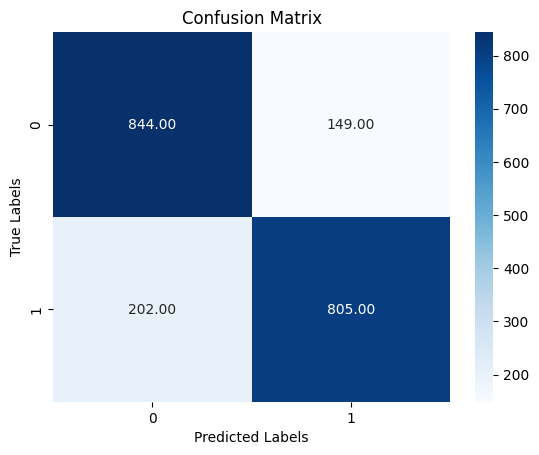

In [37]:

sns.heatmap(confusion_matrix(labels, preds), annot=True, fmt="5.2f", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")